# Exotic Option Pricing: Worst-of Down-and-In Barrier Put
**Underlyings:** Shell (SHEL) & TotalEnergies (TTE)  
**Method:** Monte Carlo with Cholesky Decomposition  

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## Загрузка рыночных данных

Загружаем исторические цены SHEL и TTE с Yahoo Finance.  
Рассчитываем: спотовые цены, историческую волатильность, корреляцию и дивидендную доходность.

In [44]:
# Тикеры
ticker1 = 'SHEL'
ticker2 = 'TTE'

# Скачиваем 2 года истории
data1 = yf.download(ticker1, period='2y', auto_adjust=True)
data2 = yf.download(ticker2, period='2y', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [57]:
# Спотовые цены (последнее закрытие)
S1_0 = float(data1['Close'].iloc[-1])
S2_0 = float(data2['Close'].iloc[-1])

# Логарифмические доходности
ret1 = np.log(data1['Close'] / data1['Close'].shift(1)).dropna()
ret2 = np.log(data2['Close'] / data2['Close'].shift(1)).dropna()

# Совмещаем по датам
combined = pd.concat([ret1, ret2], axis=1, join='inner')
combined.columns = [ticker1, ticker2]

# Историческая волатильность (годовая)
sigma1 = float(combined[ticker1].std() * np.sqrt(252))
sigma2 = float(combined[ticker2].std() * np.sqrt(252))

# Корреляция
rho = float(combined[ticker1].corr(combined[ticker2]))

raw_q1 = info1.get('dividendYield', None)
raw_q2 = info2.get('dividendYield', None)


print(f'{ticker1}:')
print(f'  Спот цена:          ${S1_0:.2f}')
print(f'  Историческая волатильность:  {sigma1:.2%}')
print(f'  Дивидендная доходность:   {raw_q1}% ')
print(f'\n{ticker2}:')
print(f'  Спот цена:          ${S2_0:.2f}')
print(f'  Историческая волатильность:  {sigma2:.2%}')
print(f'  Дивидендная доходность:   {raw_q2}%')
print(f'\nКорреляция:       {rho:.4f}')

SHEL:
  Спот цена:          $93.10
  Историческая волатильность:  21.31%
  Дивидендная доходность:   3.2% 

TTE:
  Спот цена:          $92.39
  Историческая волатильность:  22.36%
  Дивидендная доходность:   3.96%

Корреляция:       0.7558


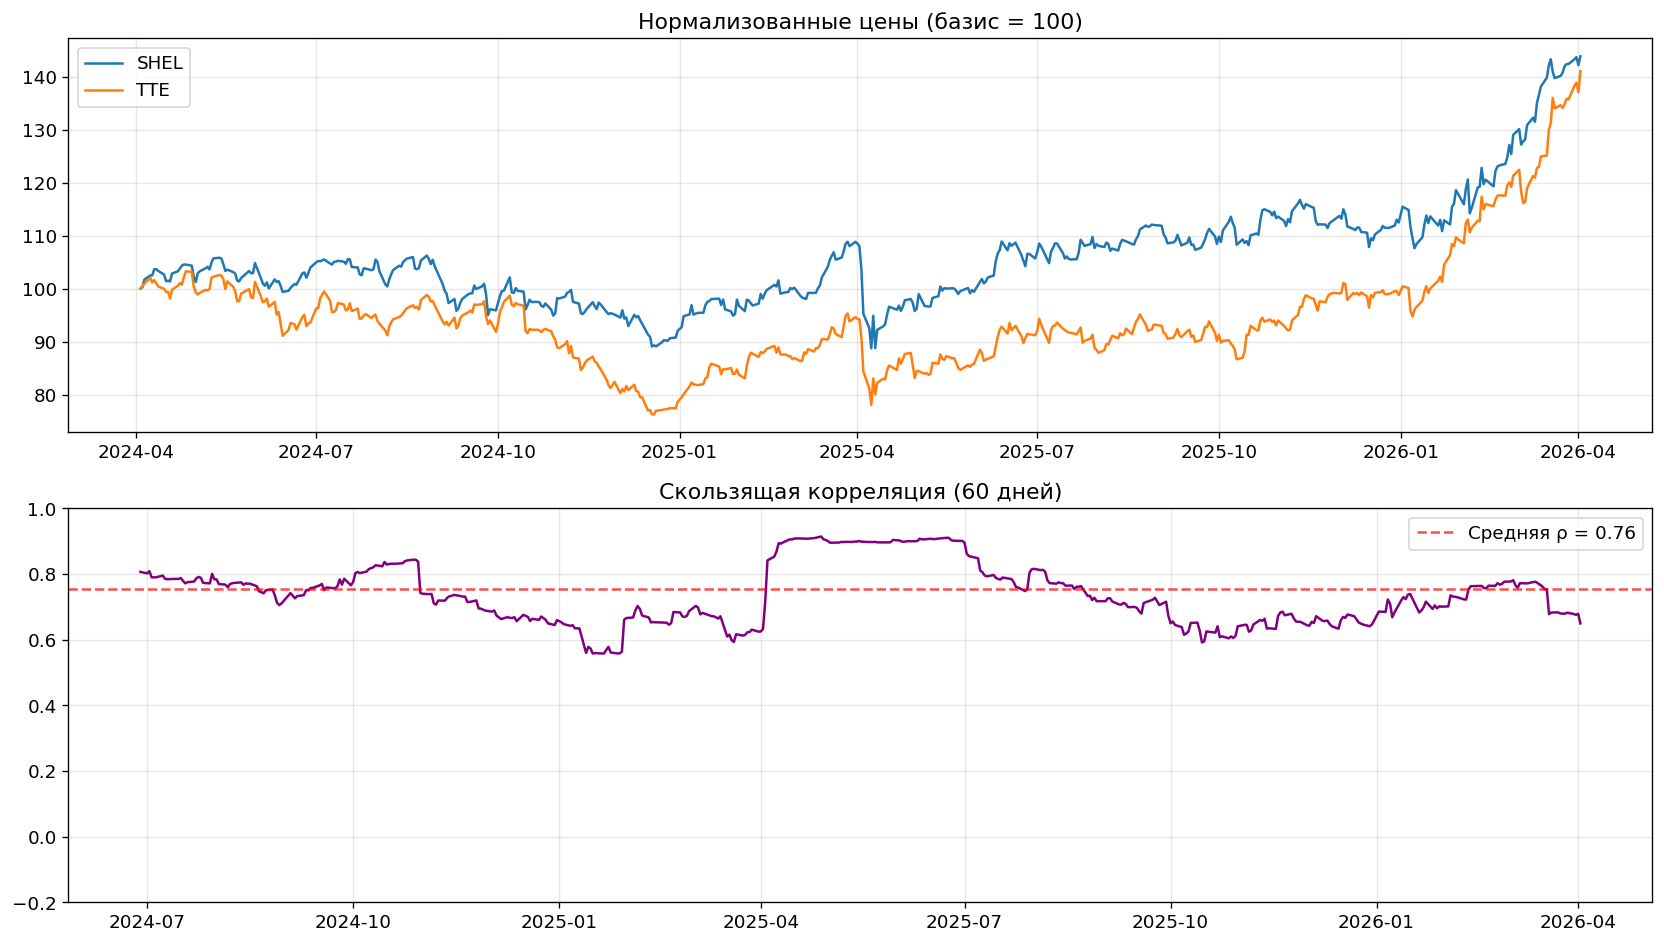

In [46]:
# Визуализация: нормализованные цены и скользящая корреляция
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Нормализованные цены
norm1 = data1['Close'] / data1['Close'].iloc[0] * 100
norm2 = data2['Close'] / data2['Close'].iloc[0] * 100
axes[0].plot(norm1.index, norm1.values, label=ticker1, linewidth=1.5)
axes[0].plot(norm2.index, norm2.values, label=ticker2, linewidth=1.5)
axes[0].set_title('Нормализованные цены (базис = 100)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Скользящая корреляция (60 дней)
rolling_corr = combined[ticker1].rolling(60).corr(combined[ticker2])
axes[1].plot(rolling_corr.index, rolling_corr.values, color='purple', linewidth=1.5)
axes[1].axhline(y=rho, color='red', linestyle='--', alpha=0.7, label=f'Средняя ρ = {rho:.2f}')
axes[1].set_title('Скользящая корреляция (60 дней)')
axes[1].set_ylim(-0.2, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Описание структуры и параметры

### Worst-of Down-and-In Barrier Put

**Механизм:**
- Опцион не активен до тех пор, пока хотя бы одна из акций не пересечёт барьер сверху вниз
- Если knock-in произошёл, на дату экспирации payoff = max(K − worst_performer, 0)
- worst_performer = min(S₁(T)/S₁(0), S₂(T)/S₂(0))

**Почему эта структура:**
- Сочетает барьерный и basket-компоненты
- Корреляция — ключевой драйвер цены - можно показать correlation sensitivity
- Cross-gamma нетривиальна
- Часто встраивается в reverse convertible / autocallable продукты

In [47]:
# Параметры структуры
T = 1.0              
K_pct = 1.0          
barrier_pct = 0.70  
r = 0.043           
N_steps = 252       
N_sims = 100_000   
seed = 42            


print(f'Тип:            Worst-of Down-and-In Barrier Put')
print(f'Базовые активы: {ticker1} (${S1_0:.2f}) & {ticker2} (${S2_0:.2f})')
print(f'Strike (K):     {K_pct:.0%} (ATM)')
print(f'Barrier:        {barrier_pct:.0%}')
print(f'Maturity (T):   {T:.0f} год')
print(f'σ ({ticker1}):       {sigma1:.2%}')
print(f'σ ({ticker2}):        {sigma2:.2%}')
print(f'ρ:              {rho:.4f}')
print(f'r (risk-free):  {r:.2%}')
print(f'q ({ticker1}):       {q1:.2%}')
print(f'q ({ticker2}):        {q2:.2%}')
print(f'N_sims:         {N_sims:,}')
print(f'N_steps:        {N_steps}')


Тип:            Worst-of Down-and-In Barrier Put
Базовые активы: SHEL ($93.10) & TTE ($92.39)
Strike (K):     100% (ATM)
Barrier:        70%
Maturity (T):   1 год
σ (SHEL):       21.31%
σ (TTE):        22.36%
ρ:              0.7558
r (risk-free):  4.30%
q (SHEL):       3.20%
q (TTE):        3.96%
N_sims:         100,000
N_steps:        252


## Монте-Карло Pricing

### Алгоритм

1. **Cholesky decomposition** для генерации коррелированных случайных величин:

$$C = LL^T, \quad L = \begin{pmatrix} 1 & 0 \\ \rho & \sqrt{1-\rho^2} \end{pmatrix}$$

2. **GBM** :

$$S_i(t+dt) = S_i(t) \cdot \exp\left[(r - q_i - \tfrac{1}{2}\sigma_i^2)dt + \sigma_i\sqrt{dt}\,\varepsilon_i\right]$$

3. **Knock-in**: если $S_1(t) \leq B_1$ или $S_2(t) \leq B_2$ для какого-либо $t$

4. **Payoff**: если knock-in, то $\max(K - \min(S_1(T)/S_1(0),\, S_2(T)/S_2(0)),\, 0)$

5. **Цена** = $e^{-rT} \cdot \mathbb{E}[\text{payoff}]$


In [48]:
def monte_carlo_price(S1_0, S2_0, sigma1, sigma2, rho, r, q1, q2,
                      K_pct, barrier_pct, T, N_steps, N_sims,
                      seed=42, return_paths=False,
                      B1_abs=None, B2_abs=None,
                      S1_init=None, S2_init=None):

    np.random.seed(seed)
    dt = T / N_steps
    
    # Начальные цены для нормализации
    if S1_init is None:
        S1_init = S1_0
    if S2_init is None:
        S2_init = S2_0
    
    # Барьеры в абсолютных ценах
    if B1_abs is None:
        B1_abs = barrier_pct * S1_0
    if B2_abs is None:
        B2_abs = barrier_pct * S2_0
    
    # Cholesky
    L22 = np.sqrt(1.0 - rho**2)
    
    # Drift & vol
    drift1 = (r - q1 - 0.5 * sigma1**2) * dt
    drift2 = (r - q2 - 0.5 * sigma2**2) * dt
    vol1 = sigma1 * np.sqrt(dt)
    vol2 = sigma2 * np.sqrt(dt)
    
    # Генерация случайных чисел
    Z1 = np.random.standard_normal((N_sims, N_steps))
    Z2_indep = np.random.standard_normal((N_sims, N_steps))
    
    # Коррелированные шоки
    eps1 = Z1
    eps2 = rho * Z1 + L22 * Z2_indep
    
    # Логарифмические приращения
    log_returns1 = drift1 + vol1 * eps1
    log_returns2 = drift2 + vol2 * eps2
    
    # Кумулятивная сумма - траектории
    cum_log1 = np.cumsum(log_returns1, axis=1)
    cum_log2 = np.cumsum(log_returns2, axis=1)
    
    # Цены
    S1_all = S1_0 * np.exp(cum_log1)
    S2_all = S2_0 * np.exp(cum_log2)
    
    # Knock-in: барьер в абсолютных ценах
    knocked_in = np.any(S1_all <= B1_abs, axis=1) | np.any(S2_all <= B2_abs, axis=1)
    
    # Финальные цены
    S1_T = S1_all[:, -1]
    S2_T = S2_all[:, -1]
    
    # Performance относительно цен
    perf1 = S1_T / S1_init
    perf2 = S2_T / S2_init
    worst = np.minimum(perf1, perf2)
    
    # Payoff
    payoffs = np.where(knocked_in, np.maximum(K_pct - worst, 0.0), 0.0)
    
    # Цена
    price = np.exp(-r * T) * np.mean(payoffs)
    std_err = np.exp(-r * T) * np.std(payoffs) / np.sqrt(N_sims)
    ki_rate = np.mean(knocked_in)
    
    if return_paths:
        n_show = min(500, N_sims)
        S1_paths = np.column_stack([np.full(n_show, S1_0), S1_all[:n_show]])
        S2_paths = np.column_stack([np.full(n_show, S2_0), S2_all[:n_show]])
        return price, std_err, ki_rate, S1_paths, S2_paths
    
    return price, std_err, ki_rate

In [49]:
# pricing
price, std_err, ki_rate, S1_paths, S2_paths = monte_carlo_price(
    S1_0, S2_0, sigma1, sigma2, rho, r, q1, q2,
    K_pct, barrier_pct, T, N_steps, N_sims, seed,
    return_paths=True
)
print(f'Цена опциона:     {price:.6f} ({price:.4%} от notional)')
print(f'Стд. ошибка:      {std_err:.6f}')
print(f'95% ДИ:           [{price - 1.96*std_err:.6f}, {price + 1.96*std_err:.6f}]')
print(f'Knock-in rate:    {ki_rate:.2%}')

Цена опциона:     0.047830 (4.7830% от notional)
Стд. ошибка:      0.000360
95% ДИ:           [0.047125, 0.048535]
Knock-in rate:    16.13%


## Вычисление греков

In [58]:
# Фиксируем барьеры и начальные цены
B1_fixed = barrier_pct * S1_0  # барьер в $
B2_fixed = barrier_pct * S2_0
 
def reprice(S1, S2, sig1, sig2, rho_val):
    v, _, _ = monte_carlo_price(
        S1, S2, sig1, sig2, rho_val, r, q1, q2,
        K_pct, barrier_pct, T, N_steps, N_sims, seed,
        B1_abs=B1_fixed, B2_abs=B2_fixed,
        S1_init=S1_0, S2_init=S2_0
    )
    return v
  
dS_pct = 0.01      # 1% bump (теперь работает!)
dS1 = S1_0 * dS_pct
dS2 = S2_0 * dS_pct
d_sigma = 0.01
d_rho = 0.01
 
# Базовая цена 
V0 = reprice(S1_0, S2_0, sigma1, sigma2, rho)
 
# DELTA
V1_up = reprice(S1_0 + dS1, S2_0, sigma1, sigma2, rho)
V1_dn = reprice(S1_0 - dS1, S2_0, sigma1, sigma2, rho)
delta1 = (V1_up - V1_dn) / (2 * dS_pct)
 
V2_up = reprice(S1_0, S2_0 + dS2, sigma1, sigma2, rho)
V2_dn = reprice(S1_0, S2_0 - dS2, sigma1, sigma2, rho)
delta2 = (V2_up - V2_dn) / (2 * dS_pct)
 
# GAMMA 
gamma1 = (V1_up - 2 * V0 + V1_dn) / (dS_pct ** 2)
gamma2 = (V2_up - 2 * V0 + V2_dn) / (dS_pct ** 2)
 
# VEGA
Vv1_up = reprice(S1_0, S2_0, sigma1 + d_sigma, sigma2, rho)
Vv1_dn = reprice(S1_0, S2_0, sigma1 - d_sigma, sigma2, rho)
vega1 = (Vv1_up - Vv1_dn) / (2 * d_sigma)
 
Vv2_up = reprice(S1_0, S2_0, sigma1, sigma2 + d_sigma, rho)
Vv2_dn = reprice(S1_0, S2_0, sigma1, sigma2 - d_sigma, rho)
vega2 = (Vv2_up - Vv2_dn) / (2 * d_sigma)
 
# CROSS-GAMMA
V_pp = reprice(S1_0 + dS1, S2_0 + dS2, sigma1, sigma2, rho)
V_pm = reprice(S1_0 + dS1, S2_0 - dS2, sigma1, sigma2, rho)
V_mp = reprice(S1_0 - dS1, S2_0 + dS2, sigma1, sigma2, rho)
V_mm = reprice(S1_0 - dS1, S2_0 - dS2, sigma1, sigma2, rho)
x_gamma = (V_pp - V_pm - V_mp + V_mm) / (4 * dS_pct * dS_pct)
 
# CORRELATION SENSITIVITY
Vr_up = reprice(S1_0, S2_0, sigma1, sigma2, min(rho + d_rho, 0.999))
Vr_dn = reprice(S1_0, S2_0, sigma1, sigma2, max(rho - d_rho, -0.999))
corr_sens = (Vr_up - Vr_dn) / (2 * d_rho)
 
greeks = {
    'price': V0,
    'delta1': delta1, 'delta2': delta2,
    'gamma1': gamma1, 'gamma2': gamma2,
    'vega1': vega1,   'vega2': vega2,
    'x_gamma': x_gamma,
    'corr_sensitivity': corr_sens
}
print(f'Цена опциона:              {V0:.6f}')
print(f'Knock-in rate:             {ki_rate:.2%}')
print(f'Delta (SHEL):              {delta1:}')
print(f'Delta (TTE):               {delta2:}')
print(f'Gamma (SHEL):              {gamma1:}')
print(f'Gamma (TTE):               {gamma2:}')
print(f'Vega (SHEL):               {vega1:}')
print(f'Vega (TTE):                {vega2:}')
print(f'Cross-Gamma:               {x_gamma:}')
print(f'Correlation Sensitivity:   {corr_sens:}')

Цена опциона:              0.047830
Knock-in rate:             16.13%
Delta (SHEL):              -0.1615340212948315
Delta (TTE):               -0.22983108154570955
Gamma (SHEL):              2.1065109351765114
Gamma (TTE):               2.1271824237019397
Vega (SHEL):               0.3027053907042568
Vega (TTE):                0.40469241032802594
Cross-Gamma:               -0.6893145554177394
Correlation Sensitivity:   -0.028659043994270703


## Графики греков vs уровень спота

Строим Delta, Gamma и Vega как функции спотовой цены SHEL (от 60% до 140% от текущей), при фиксированном TTE.

In [59]:
N_sims_plot = 100_000

def reprice_fast(S1, S2, sig1, sig2, rho_val):
    v, _, _ = monte_carlo_price(
        S1, S2, sig1, sig2, rho_val, r, q1, q2,
        K_pct, barrier_pct, T, N_steps, N_sims_plot, seed,
        B1_abs=B1_fixed, B2_abs=B2_fixed,
        S1_init=S1_0, S2_init=S2_0
    )
    return v

# Диапазон спотов
spot_range = np.linspace(0.60, 1.40, 17)
spot_levels = spot_range * S1_0

deltas_plot = []
gammas_plot = []
vegas_plot = []

for i, S1 in enumerate(spot_levels):
    dS = S1 * dS_pct
    print(f'  [{i+1:2d}/{len(spot_levels)}] S1 = ${S1:.2f} ({spot_range[i]:.0%})')
    
    V0_i = reprice_fast(S1, S2_0, sigma1, sigma2, rho)
    V_up_i = reprice_fast(S1 + dS, S2_0, sigma1, sigma2, rho)
    V_dn_i = reprice_fast(S1 - dS, S2_0, sigma1, sigma2, rho)
    
    deltas_plot.append((V_up_i - V_dn_i) / (2 * dS_pct))
    gammas_plot.append((V_up_i - 2 * V0_i + V_dn_i) / (dS_pct ** 2))
    
    Vv_up_i = reprice_fast(S1, S2_0, sigma1 + d_sigma, sigma2, rho)
    Vv_dn_i = reprice_fast(S1, S2_0, sigma1 - d_sigma, sigma2, rho)
    vegas_plot.append((Vv_up_i - Vv_dn_i) / (2 * d_sigma))

  [ 1/17] S1 = $55.86 (60%)
  [ 2/17] S1 = $60.51 (65%)
  [ 3/17] S1 = $65.17 (70%)
  [ 4/17] S1 = $69.82 (75%)
  [ 5/17] S1 = $74.48 (80%)
  [ 6/17] S1 = $79.13 (85%)
  [ 7/17] S1 = $83.79 (90%)
  [ 8/17] S1 = $88.44 (95%)
  [ 9/17] S1 = $93.10 (100%)
  [10/17] S1 = $97.75 (105%)
  [11/17] S1 = $102.41 (110%)
  [12/17] S1 = $107.06 (115%)
  [13/17] S1 = $111.72 (120%)
  [14/17] S1 = $116.37 (125%)
  [15/17] S1 = $121.03 (130%)
  [16/17] S1 = $125.68 (135%)
  [17/17] S1 = $130.34 (140%)


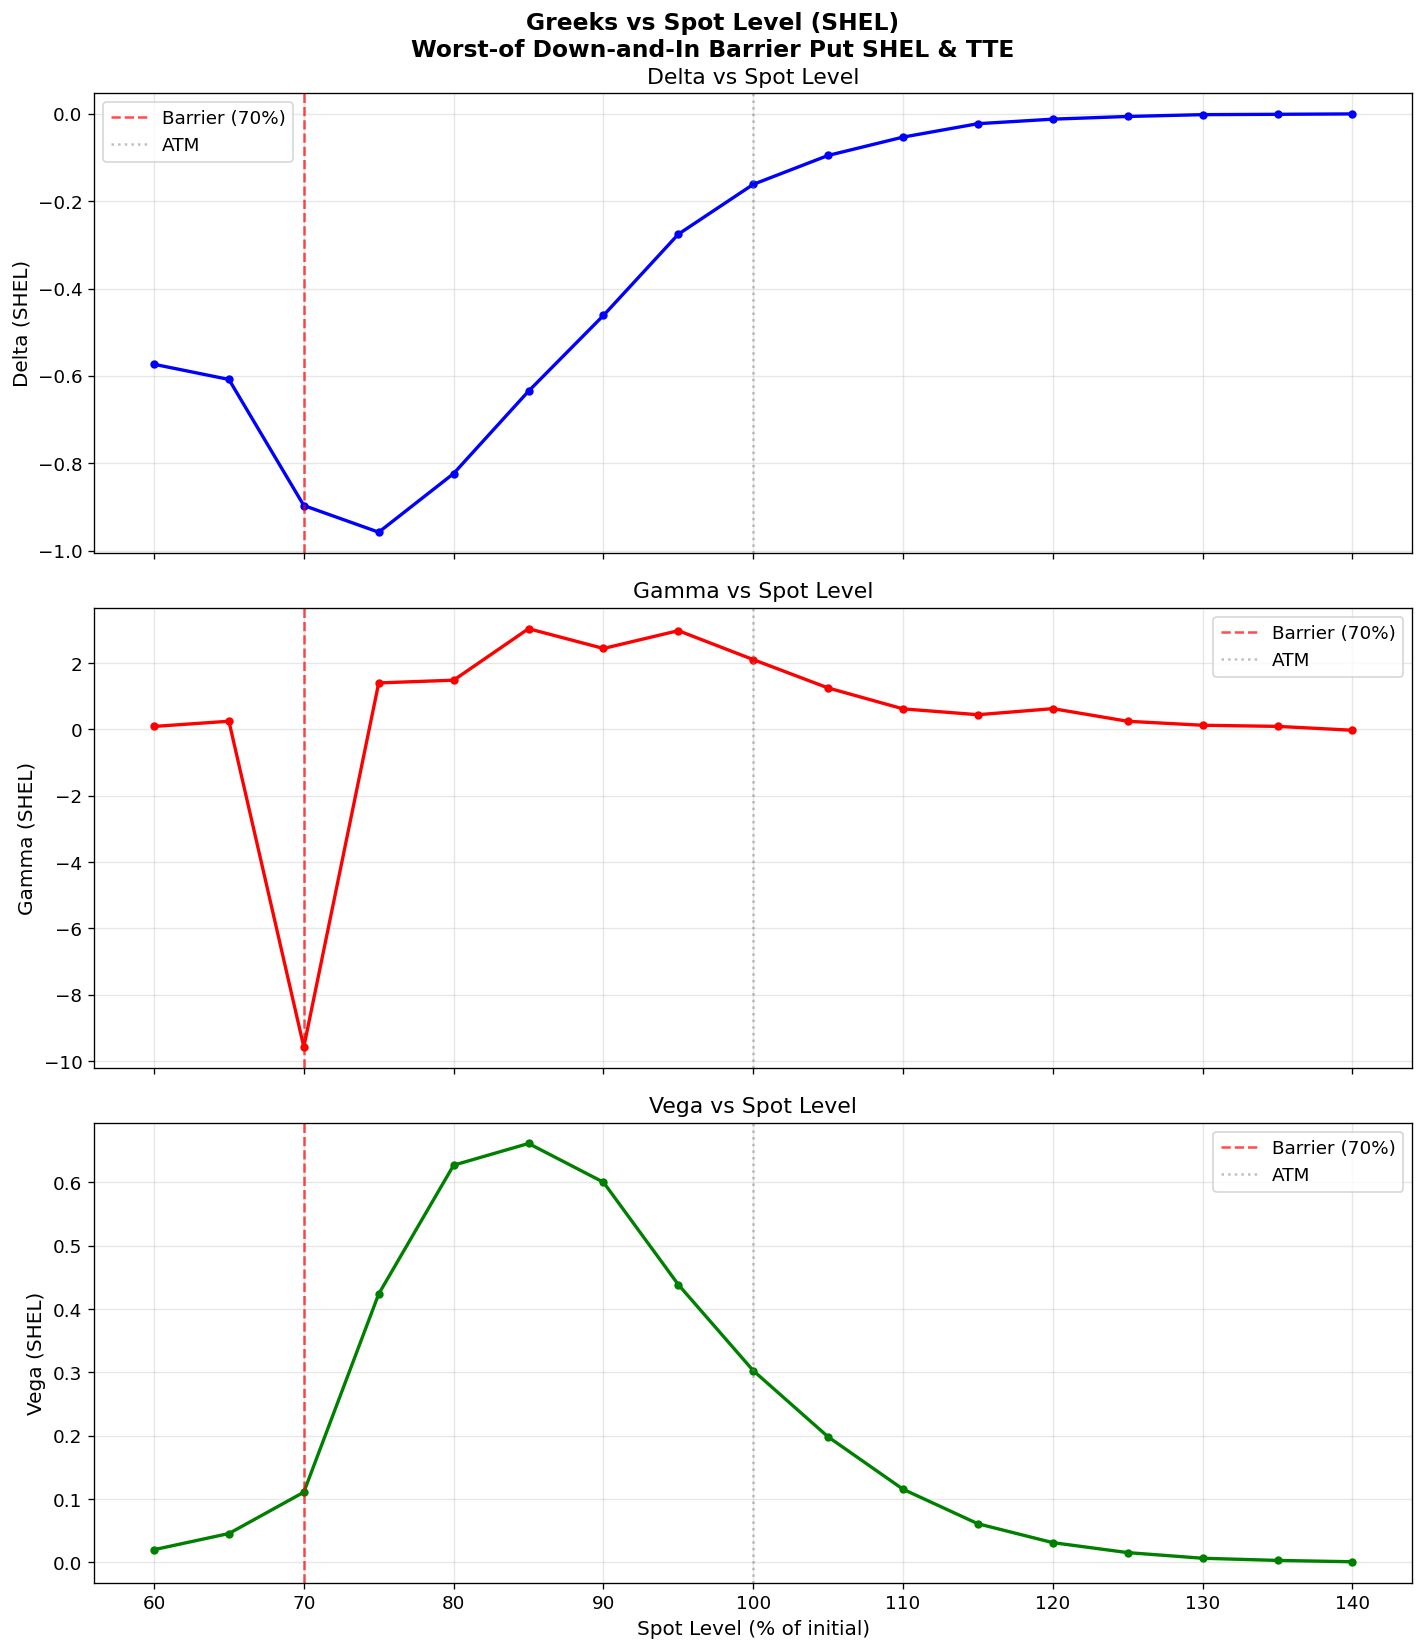

In [53]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
fig.suptitle('Greeks vs Spot Level (SHEL)\nWorst-of Down-and-In Barrier Put SHEL & TTE',
             fontsize=14, fontweight='bold')

x = spot_range * 100

# Delta
axes[0].plot(x, deltas_plot, 'b-o', linewidth=2, markersize=4)
axes[0].axvline(x=barrier_pct * 100, color='red', linestyle='--', alpha=0.7, label=f'Barrier ({barrier_pct:.0%})')
axes[0].axvline(x=100, color='gray', linestyle=':', alpha=0.5, label='ATM')
axes[0].set_ylabel('Delta (SHEL)', fontsize=12)
axes[0].set_title('Delta vs Spot Level')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gamma
axes[1].plot(x, gammas_plot, 'r-o', linewidth=2, markersize=4)
axes[1].axvline(x=barrier_pct * 100, color='red', linestyle='--', alpha=0.7, label=f'Barrier ({barrier_pct:.0%})')
axes[1].axvline(x=100, color='gray', linestyle=':', alpha=0.5, label='ATM')
axes[1].set_ylabel('Gamma (SHEL)', fontsize=12)
axes[1].set_title('Gamma vs Spot Level')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Vega
axes[2].plot(x, vegas_plot, 'g-o', linewidth=2, markersize=4)
axes[2].axvline(x=barrier_pct * 100, color='red', linestyle='--', alpha=0.7, label=f'Barrier ({barrier_pct:.0%})')
axes[2].axvline(x=100, color='gray', linestyle=':', alpha=0.5, label='ATM')
axes[2].set_ylabel('Vega (SHEL)', fontsize=12)
axes[2].set_xlabel('Spot Level (% of initial)', fontsize=12)
axes[2].set_title('Vega vs Spot Level')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('greeks_vs_spot.png', dpi=150, bbox_inches='tight')
plt.show()

## Визуализация путей Монте-Карло

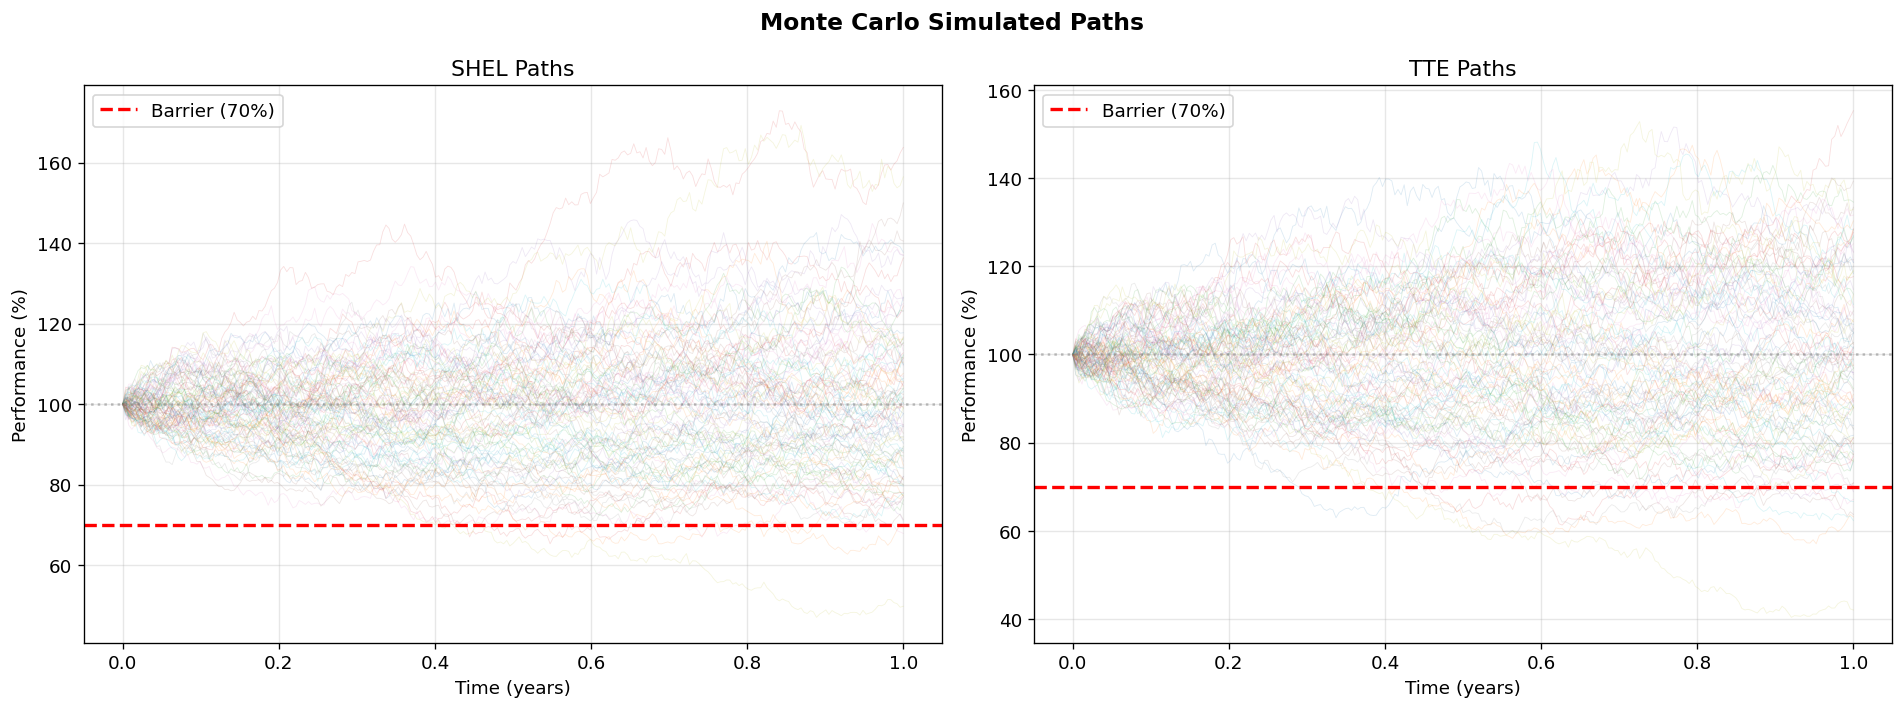

In [54]:
t_grid = np.linspace(0, T, N_steps + 1)
n_show = min(100, S1_paths.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Monte Carlo Simulated Paths', fontsize=14, fontweight='bold')

# SHEL
for i in range(n_show):
    axes[0].plot(t_grid, S1_paths[i] / S1_0 * 100, alpha=0.15, linewidth=0.5)
axes[0].axhline(y=barrier_pct * 100, color='red', linestyle='--', linewidth=2, label=f'Barrier ({barrier_pct:.0%})')
axes[0].axhline(y=100, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Performance (%)')
axes[0].set_title(f'{ticker1} Paths')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# TTE
for i in range(n_show):
    axes[1].plot(t_grid, S2_paths[i] / S2_0 * 100, alpha=0.15, linewidth=0.5)
axes[1].axhline(y=barrier_pct * 100, color='red', linestyle='--', linewidth=2, label=f'Barrier ({barrier_pct:.0%})')
axes[1].axhline(y=100, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Time (years)')
axes[1].set_ylabel('Performance (%)')
axes[1].set_title(f'{ticker2} Paths')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mc_paths.png', dpi=150, bbox_inches='tight')
plt.show()

## Зависимость цены от корреляции

In [55]:
%%time

rho_range = np.linspace(-0.5, 0.95, 15)
prices_rho = []

for i, rho_val in enumerate(rho_range):
    print(f'  [{i+1:2d}/{len(rho_range)}] ρ = {rho_val:.2f}')
    v = reprice_fast(S1_0, S2_0, sigma1, sigma2, rho_val)
    prices_rho.append(v)


  [ 1/15] ρ = -0.50
  [ 2/15] ρ = -0.40
  [ 3/15] ρ = -0.29
  [ 4/15] ρ = -0.19
  [ 5/15] ρ = -0.09
  [ 6/15] ρ = 0.02
  [ 7/15] ρ = 0.12
  [ 8/15] ρ = 0.22
  [ 9/15] ρ = 0.33
  [10/15] ρ = 0.43
  [11/15] ρ = 0.54
  [12/15] ρ = 0.64
  [13/15] ρ = 0.74
  [14/15] ρ = 0.85
  [15/15] ρ = 0.95
CPU times: user 17.9 s, sys: 3.82 s, total: 21.8 s
Wall time: 23.5 s


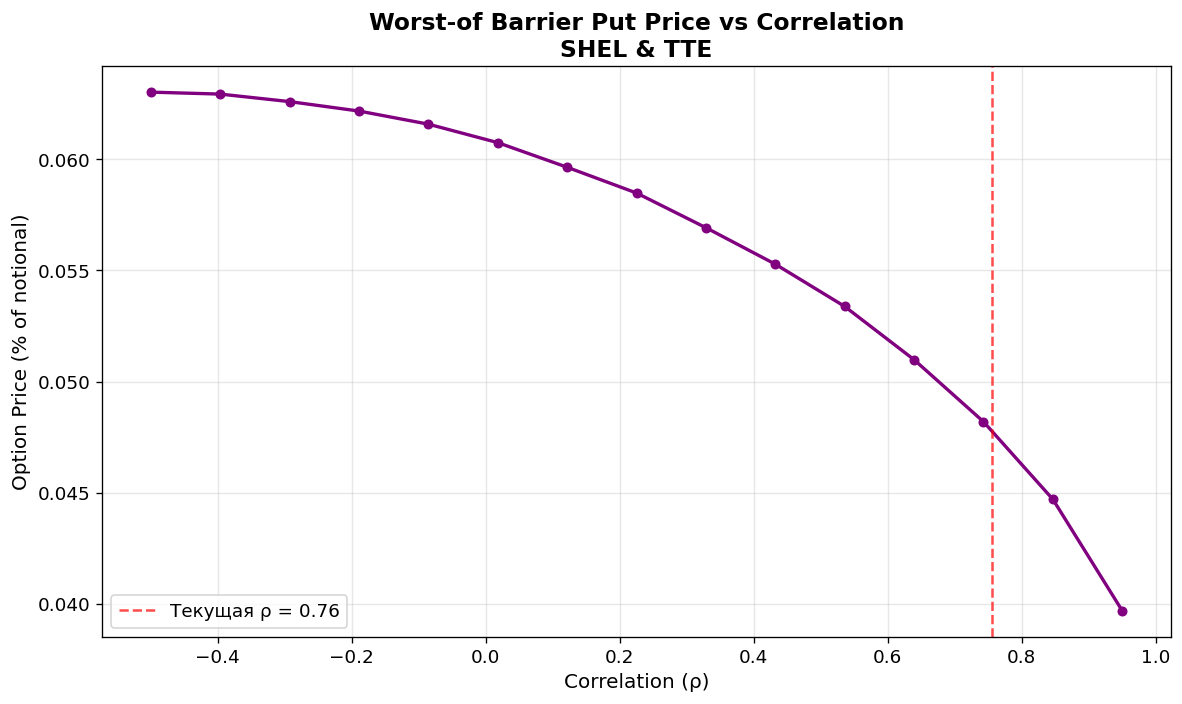

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(rho_range, prices_rho, 'purple', linewidth=2, marker='o', markersize=5)
ax.axvline(x=rho, color='red', linestyle='--', alpha=0.7, label=f'Текущая ρ = {rho:.2f}')
ax.set_xlabel('Correlation (ρ)', fontsize=12)
ax.set_ylabel('Option Price (% of notional)', fontsize=12)
ax.set_title('Worst-of Barrier Put Price vs Correlation\nSHEL & TTE',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('correlation_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## Комментарий по грекам

### Delta
- **SHEL:** −0.16  
- **TTE:** −0.23  

Отрицательная дельта у обоих активов, что обычно для длинного пут-опциона.  
У TTE дельта больше по модулю из-за более высокой волатильности (22.4% против 21.3%) и дивидендной доходности - TTE вероятнее станет **worst performer**.

**Поведение по споту:**  
- При споте 140% от начального дельта ≈ 0 (knock‑in маловероятен).  
- При снижении к барьеру (70%) дельта уходит до **−0.95** (высокая чувствительность).  
- Ниже барьера - дельта слегка отскакивает, опцион активирован и ведёт себя как обычный deep ITM пут.

### Gamma
- **SHEL:** +2.11  
- **TTE:** +2.13  

Резкий **отрицательный пик на барьере** (70%) из-за разрывности payoff при knock‑in.  
- Выше барьера: гамма положительна (дельта ускоряется к минусу).  
- Ниже барьера: гамма резко уходит в минус (дельта стабилизируется).

**Проблема:** **pin risk** вблизи барьера — маркет-мейкер вынужден постоянно перебалансировать хедж, покупая дорого и продавая дёшево.


### Vega
- **SHEL:** +0.30  
- **TTE:** +0.40  

Вега положительна (рост волатильности, следовательно выше вероятность knock‑in и выше ожидаемый payoff).  
Максимум веги в зоне **80–90%** от начального спота — там волатильность сильнее всего влияет на вероятность пробития барьера.  
При очень низком споте (опцион уже activated) или очень высоком (knock‑in невозможен) вега стремится к нулю.


### Cross-Gamma
**Значение:** −0.69  

Отрицательная кросс-гамма: при падении TTE дельта по SHEL становится более отрицательной (растёт по модулю).  
**Интуиция:** падение TTE приближает knock‑in, после чего payoff зависит от worst performer, и SHEL становится значимее для хеджа.

**Практическое следствие:** хеджи по двум активам нельзя строить независимо — движение одного актива меняет требуемый хедж по другому. Это усложняет и удорожает risk management.


### Correlation Sensitivity
**Значение:** −0.029  

Отрицательная чувствительность: при росте корреляции оба актива движутся синхроннее, worst performer в среднем ближе к лучшему - опцион дешевеет.

**При текущей ρ = 0.76 цена опциона = 4.78%**  
- Если ρ упадёт до 0, цена вырастет до **~6.1%** (+27%)  
- Если ρ вырастет до 0.95, цена упадёт до **~4.0%** (−16%)

**Это основной нехеджируемый риск** для структурированных продуктов: корреляцией нельзя торговать напрямую (correlation swaps неликвидны), поэтому банки закладывают дополнительную маржу в цену.